<a href="https://colab.research.google.com/github/MelB18/Quanten/blob/main/QAOA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Install required packages.
!pip install qiskit
!pip install pylatexenc

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 36.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 48.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.9/54.9 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 2.3 MB/s eta 0:00:00


In [8]:
!pip install 'qiskit[visualization]' qiskit-ibm-runtime qiskit-aer
# Core Qiskit imports
from qiskit import QuantumCircuit
from qiskit.visualization import plot_histogram
from qiskit_aer import AerSimulator
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

# IBM Runtime specific imports
from qiskit_ibm_runtime import SamplerV2 as Sampler, QiskitRuntimeService

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 14.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 86.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 412.6/412.6 kB 29.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 120.8/120.8 kB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.7/95.7 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 224.2/224.2 kB 17.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.6/76.6 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.2/130.2 kB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 541.5/541.5 kB 35.5 MB/s eta 0:00:00


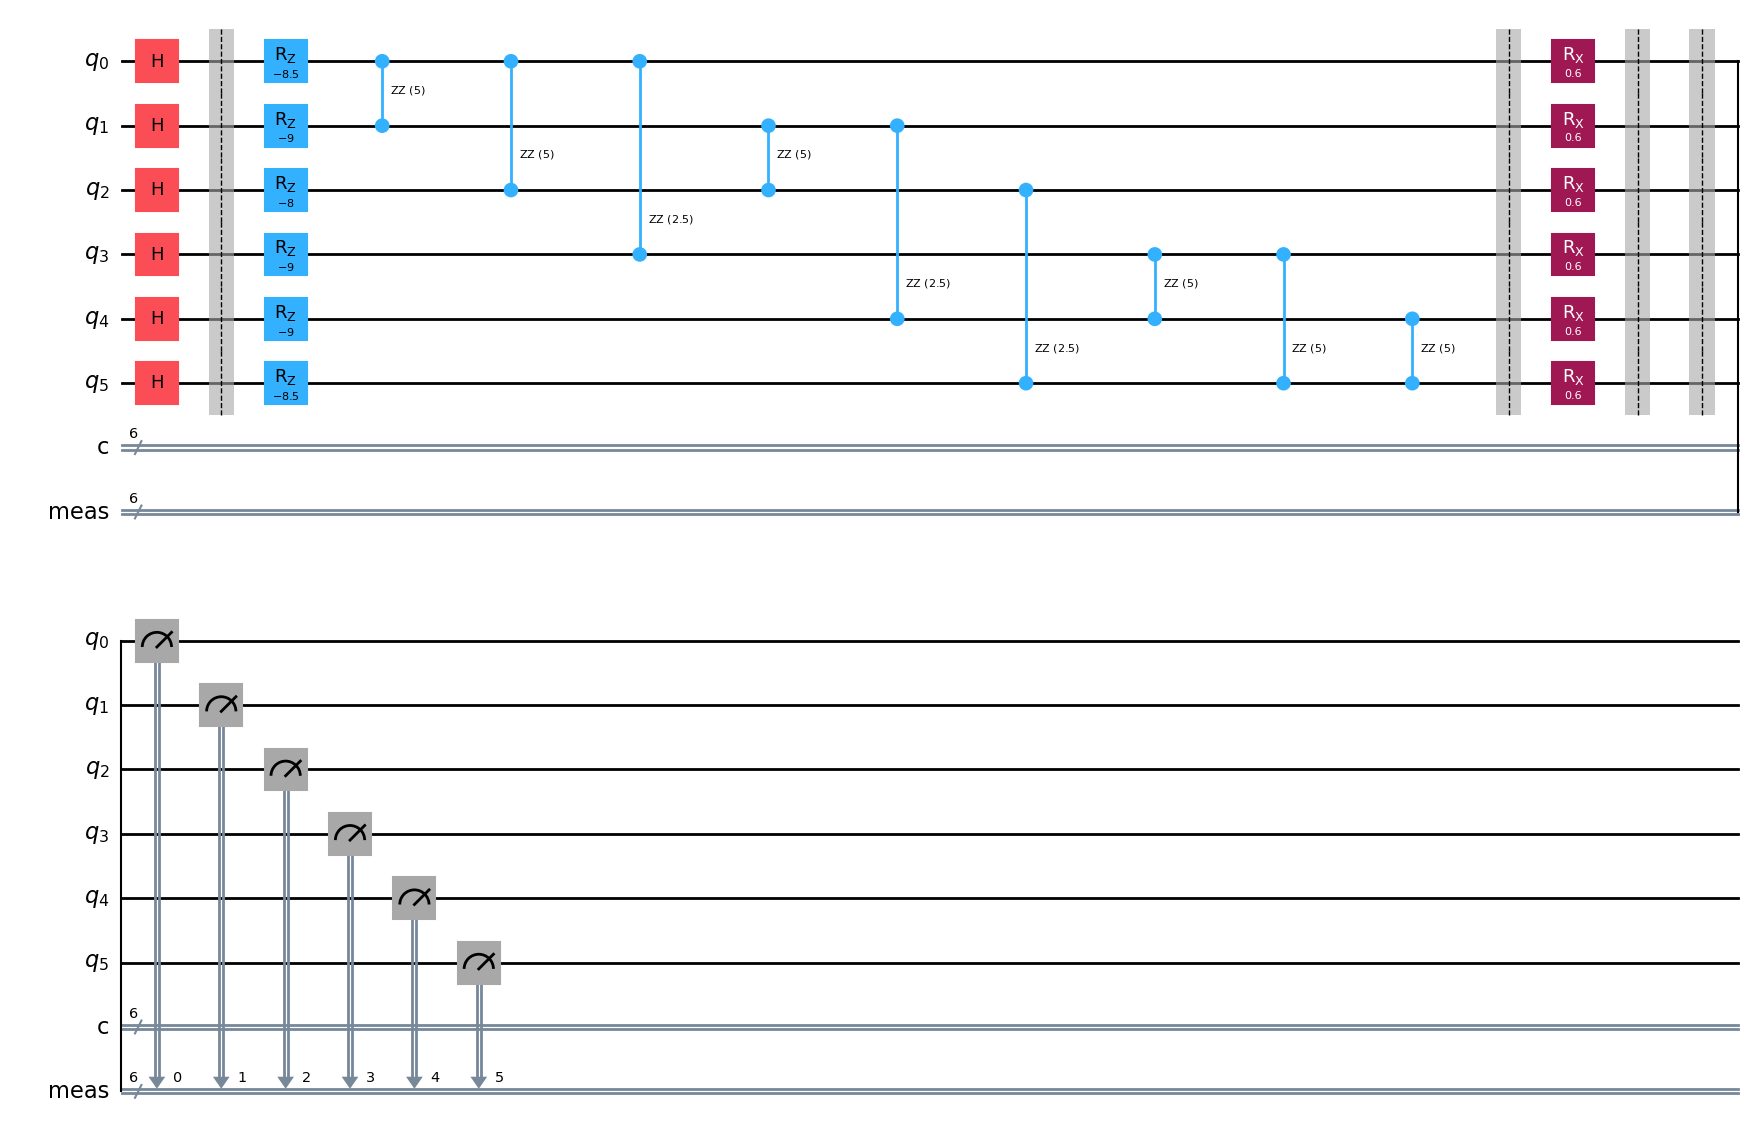

In [15]:


gamma = 0.5
beta = 0.3

qc = QuantumCircuit(6, 6)

# ==========================================
# 1. Superposition
# ==========================================

for q in range(6):
  qc.h(q)

qc.barrier()


# ==========================================
# 2. Cost Layer
# ==========================================

h = [-8.5, -9.0, -8.0, -9.0, -9.0, -8.5]

for q, coeff in enumerate(h):
  qc.rz(2 * gamma * coeff, q)

zz_terms = [
(0, 1, 5.0),
(0, 2, 5.0),
(0, 3, 2.5),
(1, 2, 5.0),
(1, 4, 2.5),
(2, 5, 2.5),
(3, 4, 5.0),
(3, 5, 5.0),
(4, 5, 5.0),
]

for q1, q2, coeff in zz_terms:
  qc.rzz(2 * gamma * coeff, q1, q2)

qc.barrier()


# ==========================================
# 3. Mixer
# ==========================================

for q in range(6):
  qc.rx(2 * beta, q)

qc.barrier()


# ==========================================
# 4. Messung
# ==========================================

#qc.measure(range(6), range(6))
qc.measure_all()

#print(qc.draw())

# Matplotlib drawing
qc.draw(output="mpl")

In [13]:
def run_circuit_and_get_counts(circuit, backend, shots=1000):
  """
  Runs a quantum circuit on a specified backend and returns the measurement counts.

  Args:
      circuit (QuantumCircuit): The quantum circuit to run.
      backend: The Qiskit backend (real device or simulator).
      shots (int): The number of shots to run the circuit.

  Returns:
      dict: A dictionary of measurement counts.
  """
  pm = generate_preset_pass_manager(backend=backend, optimization_level=1)
  isa_circuit = pm.run(circuit)
  sampler = Sampler(mode=backend)
  job = sampler.run([isa_circuit], shots=shots)
  result = job.result()

  return result[0].data.meas.get_counts()

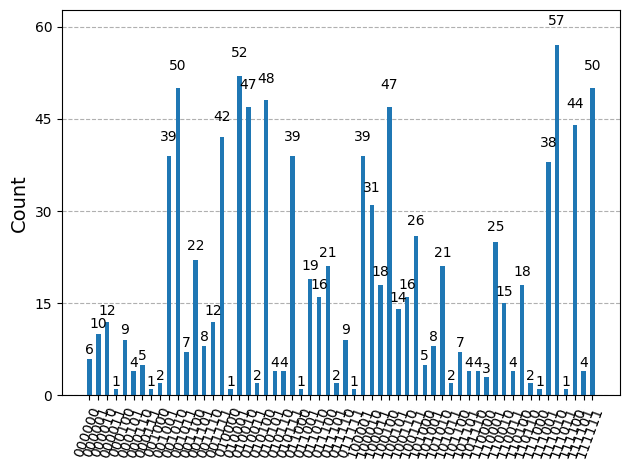

In [18]:
backend = AerSimulator()
counts = run_circuit_and_get_counts(qc, backend, shots=1000)

plot_histogram(counts)